# LSZ Spectroscopy — noise study

Runs the protocol under four noise conditions and compares the recovered spectrum:

1. **Noiseless** baseline — also checked against the theoretical values.
2. **Ramp only** noise.
3. **Wait only** noise.
4. **Ramp + Wait** noise.

For the three noisy cases we plot the difference in **frequencies, energies, amplitudes
and phases** relative to the noiseless baseline. Finally we compare the **estimated noise
rates** (for the cases involving wait noise) against the configured real rates.

The whole run is driven from `noise_study_config.yaml`: this notebook writes that file
from the config below and then reads it back, so the YAML is the single source of truth.


## Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import yaml

sys.path.append('/Users/omichel/Desktop/qilimanjaro/projects/LZS_spectroscopy/lsz_spectroscopy/src')

from lsz_experiment import run_experiment_sweep, set_global_seed, LSZ_experiment
from diagnostics import run_full_diagnostics
from dephasing import predict_gamma_rates
from noise_study import (
    aligned_from_results,
    plot_baseline_vs_theory,
    plot_noisy_differences,
    plot_noise_estimation,
    plot_run_vs_theory_scatter,
    plot_run_vs_theory_index,
)

ket0 = qt.basis(2, 0)
ket1 = qt.basis(2, 1)

## Configuration → YAML → read back

The dictionary below is the test case (the uncommented "2-qubit GHz" config from
`LSZ_main.ipynb`). We dump it to `noise_study_config.yaml`, then immediately reload it
so every run downstream uses the file, not the in-memory dict.

In [2]:
config = {
    'protocol': {
        'epsilon': 1,
        'max_wait_time': 100,
        'ramp_time': 1,
        'n_steps': 201,
        'dt': 0.1,
    },
    'hamiltonian': {
        'local_z': [1, 1],
        'local_x': [1, 1],
        'two_body': [1],
    },
    'decoherence': {
        't1_rates': [0.011, 0.009],   # amplitude damping (kappa_T1)
        't2_rates': [0.008, 0.011],   # pure dephasing   (kappa_phi)
    },
    'ramps': {
        'up_assymetry_coefficients': [10, 1],
        'down_assymetry_coefficients': [10, 1],
        'average_ramp_error': 0.0,
        'average_wait_error': 0.0,
    },
    'initial_state': {'preset': 'minus'},
    'run': {'noise_seed': 0},
}

CONFIG_PATH = 'noise_study_config.yaml'
with open(CONFIG_PATH, 'w') as f:
    yaml.safe_dump(config, f, sort_keys=False)
print(f'Wrote {CONFIG_PATH}')

# Read it back — this is what the rest of the notebook uses.
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)
print(yaml.safe_dump(cfg, sort_keys=False))

Wrote noise_study_config.yaml
protocol:
  epsilon: 1
  max_wait_time: 100
  ramp_time: 1
  n_steps: 201
  dt: 0.1
hamiltonian:
  local_z:
  - 1
  - 1
  local_x:
  - 1
  - 1
  two_body:
  - 1
decoherence:
  t1_rates:
  - 0.011
  - 0.009
  t2_rates:
  - 0.008
  - 0.011
ramps:
  up_assymetry_coefficients:
  - 10
  - 1
  down_assymetry_coefficients:
  - 10
  - 1
  average_ramp_error: 0.0
  average_wait_error: 0.0
initial_state:
  preset: minus
run:
  noise_seed: 0



In [3]:
# Unpack the loaded config into working variables.
epsilon       = cfg['protocol']['epsilon']
max_wait_time = cfg['protocol']['max_wait_time']
ramp_time     = cfg['protocol']['ramp_time']
n_steps       = cfg['protocol']['n_steps']
dt            = cfg['protocol']['dt']

local_z_list = np.array(cfg['hamiltonian']['local_z'], dtype=float)
local_x_list = np.array(cfg['hamiltonian']['local_x'], dtype=float)
zz_terms     = np.array(cfg['hamiltonian']['two_body'], dtype=float)
n_qubits     = len(local_z_list)

t1_rates = cfg['decoherence']['t1_rates']
t2_rates = cfg['decoherence']['t2_rates']

up_assymetry_coefficients   = cfg['ramps']['up_assymetry_coefficients']
down_assymetry_coefficients = cfg['ramps']['down_assymetry_coefficients']
average_ramp_error          = cfg['ramps']['average_ramp_error']
average_wait_error          = cfg['ramps']['average_wait_error']

noise_seed = cfg['run']['noise_seed']

def build_initial_state(preset, n_qubits):
    if preset == 'minus':
        return qt.tensor([1/np.sqrt(2)*(ket0 - ket1)] * n_qubits)
    if preset == 'plus':
        return qt.tensor([1/np.sqrt(2)*(ket0 + ket1)] * n_qubits)
    if preset == 'minus_plus':
        return qt.tensor([1/np.sqrt(2)*(ket0 - ket1), 1/np.sqrt(2)*(ket0 + ket1)])
    raise ValueError(f'unknown initial-state preset: {preset!r}')

psi0 = build_initial_state(cfg['initial_state']['preset'], n_qubits)

H_target_dict = {'local_z': local_z_list, 'local_x': local_x_list, 'two_body': zz_terms}

n_sims = int(max_wait_time * 10)
tw_l = np.linspace(0, max_wait_time, n_sims)

print('n_qubits:', n_qubits, '| n_sims:', n_sims, '| dt:', dt)

n_qubits: 2 | n_sims: 1000 | dt: 0.1


## True spectrum (theory reference)

The instantaneous spectrum at the ramp midpoint gives the true energy levels and
transition frequencies the diagnostics are compared against.

In [4]:
preview = LSZ_experiment(n_qubits, epsilon, H_target_dict, ramp_time, 2, dt,
                         up_assymetry_factors=up_assymetry_coefficients,
                         down_assymetry_factors=down_assymetry_coefficients,
                         ramp_error=average_ramp_error,
                         wait_error=average_wait_error)

t_list, egvals, egvecs = preview.show_spectrum(n_steps)
midpoint = int(len(t_list) / 2)
egvals_midpoint = egvals[midpoint]
print('Spectrum at midpoint:', egvals_midpoint)

# True pairwise transition frequencies (upper triangular), the reference ordering
# used to align modes across all runs.
true_differences = np.array([
    egvals_midpoint[j] - egvals_midpoint[i]
    for i in range(len(egvals_midpoint))
    for j in range(i + 1, len(egvals_midpoint))
])
print('True transition energy differences:', np.round(true_differences, 6))

Spectrum at midpoint: [-2.60387547 -1.          0.10991626  3.49395921]
True transition energy differences: [1.603875 2.713792 6.097835 1.109916 4.493959 3.384043]


## Run the four noise conditions

Each case re-seeds the RNG to the same `noise_seed` so the noise realizations are
comparable, runs the sweep, then the full diagnostics. We collect the `results` dict
for every case.

> Note: `run_full_diagnostics` produces its own plots per run (spectrum, fit, matching,
> turnpike, state validation). Those are the per-run diagnostics; the cross-run
> comparison plots come afterwards.


CASE: Noiseless   (r_noise=False, w_noise=False)
  [##############################] 100.00%  iter 1000/1000  elapsed   53.0s  ETA   -0.0s


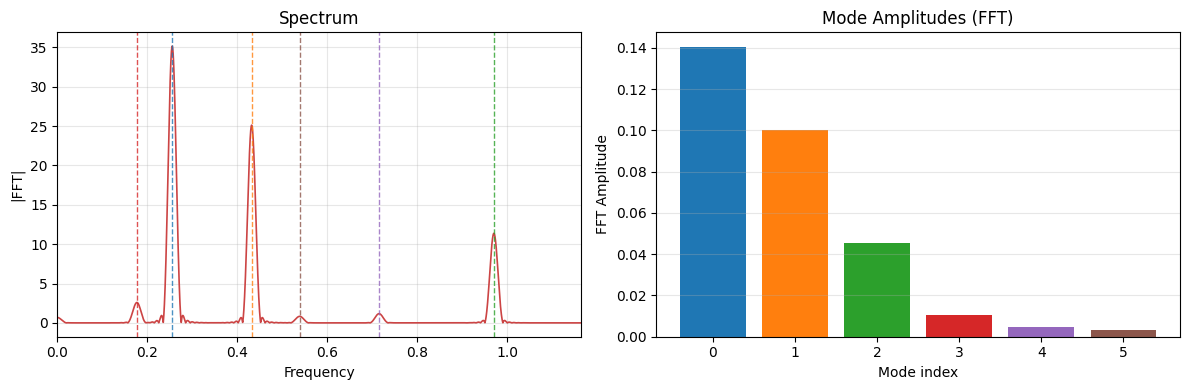


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.255264        5.5586
  2        0.431913        5.1534
  3        0.970500        2.0858
  4        0.176807        5.8754
  5        0.715236        2.8100
  6        0.538707        3.1175


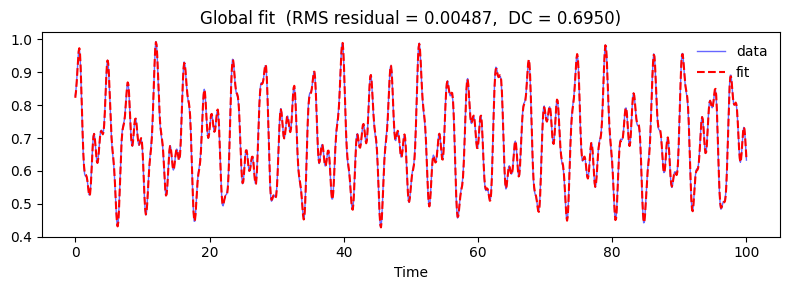

Amplitudes: [0.07024407 0.05021838 0.02273419 0.00511689 0.00231029 0.00165463]
Decay rates: [1.e-12 1.e-12 1.e-12 1.e-12 1.e-12 1.e-12]
DC (fitted): 0.694984577150615   DC (mean): 0.6963829895003321

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.603870        1.603875       -0.000005          -0.000%
   2        2.713789        2.713792       -0.000002          -0.000%
   3        6.097833        6.097835       -0.000002          -0.000%
   4        1.110910        1.109916       +0.000994          +0.090%
   5        4.493963        4.493959       +0.000004          +0.000%
   6        3.384798        3.384043       +0.000755          +0.022%
--------------------------------------------------------------------
                        RMS error:

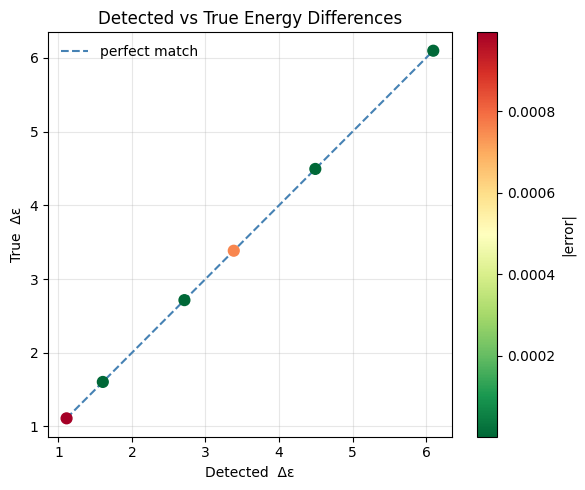

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... found solution explaining 4/6 (67%) of observations.
  Trying match threshold = 20% ... found solution explaining 4/6 (67%) of observations.

  Running greedy solver for comparison...
  Greedy explains 4/6 (67%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.6039), np.float64(2.713), np.float64(6.0978)]
    Explains 4/6 observed differences (67%)

                  E0      E1      E2      E3
True:         0.0000  1.6039  2.7138  6.0978
Forward:      0.0000  1.6039  2.7130  6.0978  <-- best
Reversed:     0.0000  3.3848  4.4940  6.0978


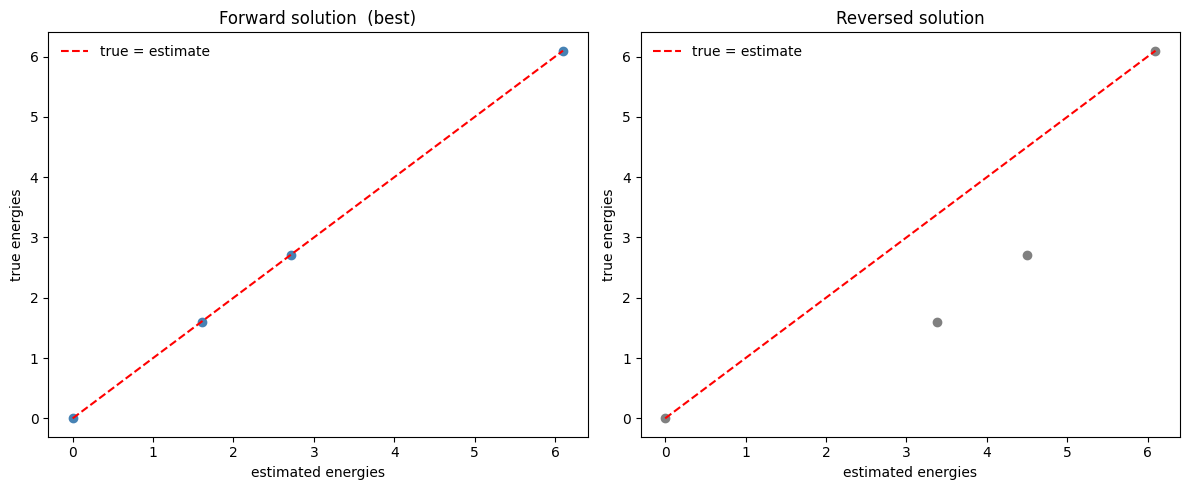

e_m:   [0.     1.6039 2.7138 6.0978]
phi_m: [0.     0.3623 0.5649 2.0987]
u_m:   [0.9114 0.2907 0.2459 0.1654]
Exact |u_m|: [0.90919677 0.29164099 0.24651995 0.1659358 ]
Exact phases (mod pi, rel to u_0): [0.         0.34583917 0.54067758 2.08449851]


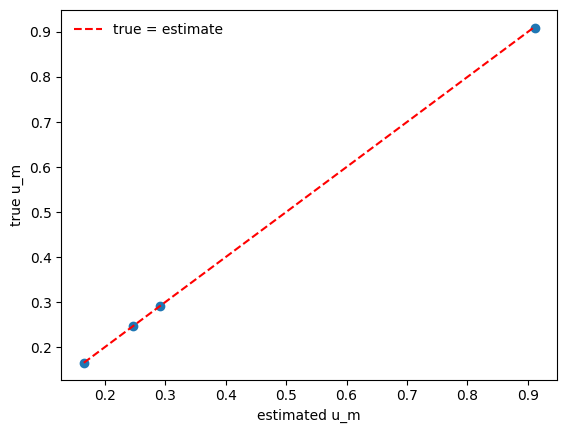

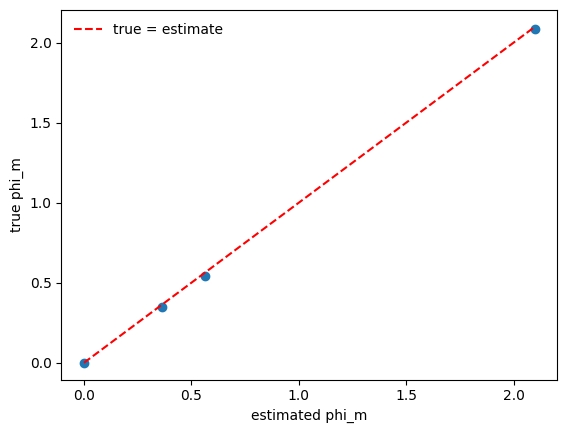


CASE: Ramp only   (r_noise=True, w_noise=False)
  [##############################] 100.00%  iter 1000/1000  elapsed  139.1s  ETA   -0.0s


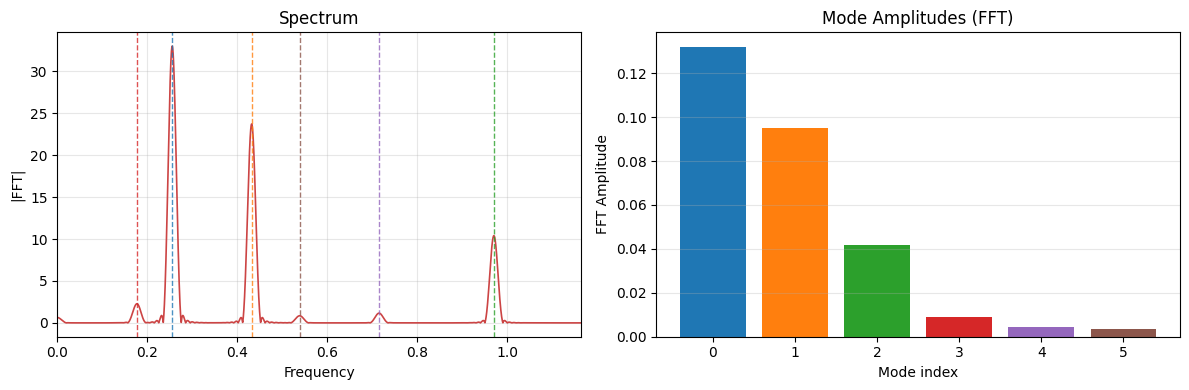


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.255264        5.5682
  2        0.431913        5.1831
  3        0.970500        2.0835
  4        0.176814        5.9112
  5        0.715238        2.7423
  6        0.538697        3.2104


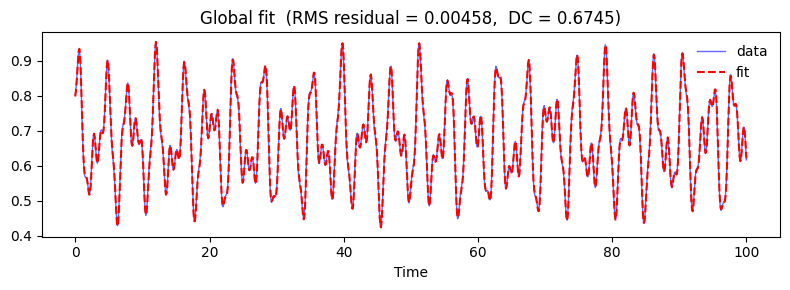

Amplitudes: [0.06597362 0.04748962 0.0207927  0.0044946  0.00229351 0.00170083]
Decay rates: [1.19894477e-06 2.10110105e-05 4.51395051e-28 5.98259017e-30
 2.03306150e-16 5.65914195e-24]
DC (fitted): 0.6745090772486602   DC (mean): 0.6758160223821151

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.603871        1.603875       -0.000004          -0.000%
   2        2.713789        2.713792       -0.000002          -0.000%
   3        6.097833        6.097835       -0.000002          -0.000%
   4        1.110955        1.109916       +0.001039          +0.094%
   5        4.493973        4.493959       +0.000014          +0.000%
   6        3.384734        3.384043       +0.000691          +0.020%
-----------------------------------------------------

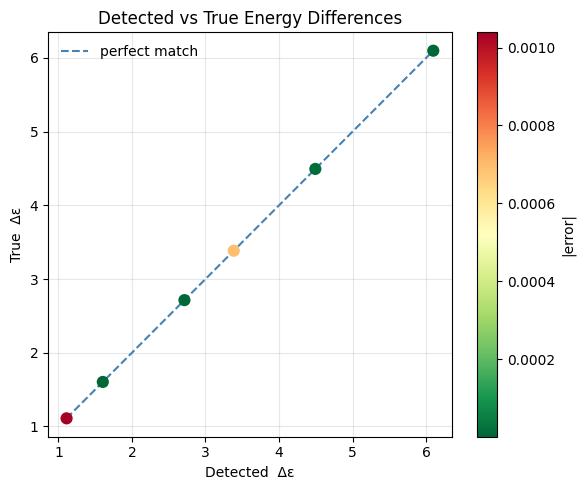

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... found solution explaining 4/6 (67%) of observations.
  Trying match threshold = 20% ... found solution explaining 4/6 (67%) of observations.

  Running greedy solver for comparison...
  Greedy explains 4/6 (67%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.6039), np.float64(2.7131), np.float64(6.0978)]
    Explains 4/6 observed differences (67%)

                  E0      E1      E2      E3
True:         0.0000  1.6039  2.7138  6.0978
Forward:      0.0000  1.6039  2.7131  6.0978  <-- best
Reversed:     0.0000  3.3847  4.4940  6.0978


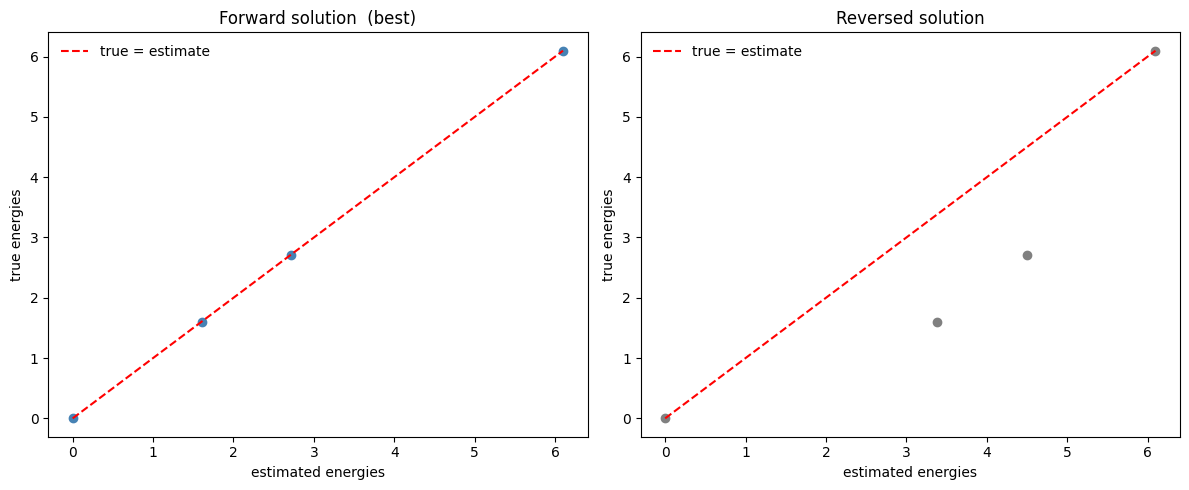

e_m:   [0.     1.6039 2.7138 6.0978]
phi_m: [0.     0.3575 0.55   2.0998]
u_m:   [0.8794 0.2811 0.2403 0.1652]
Exact |u_m|: [0.90919677 0.29164099 0.24651995 0.1659358 ]
Exact phases (mod pi, rel to u_0): [0.         0.34583917 0.54067758 2.08449851]


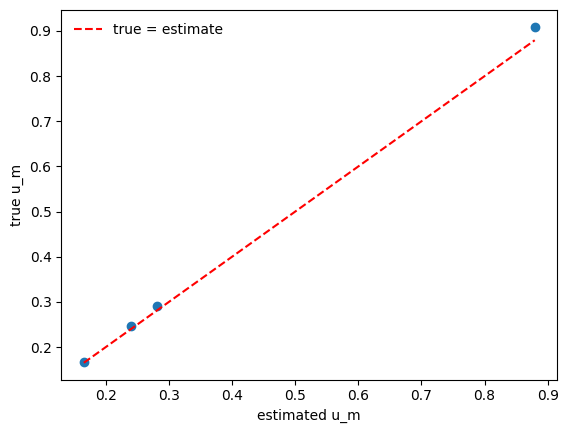

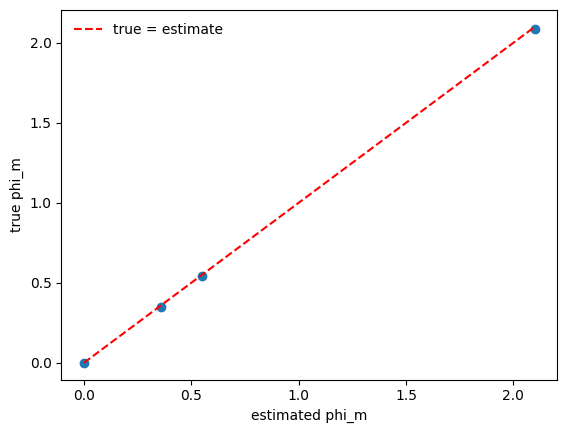

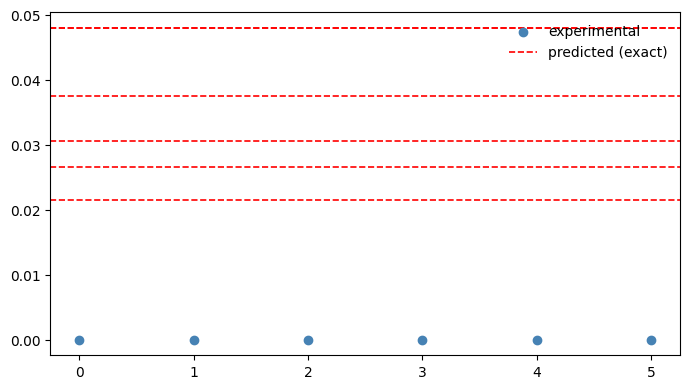

Exact lambdas (predicted): [0.0265 0.0215 0.048  0.048  0.0305 0.0375]
Experimental lambdas: [1.19894477e-06 2.10110105e-05 4.51395051e-28 5.98259017e-30
 2.03306150e-16 5.65914195e-24]

CASE: Wait only   (r_noise=False, w_noise=True)
  [##############################] 100.00%  iter 1000/1000  elapsed  143.2s  ETA   -0.0s


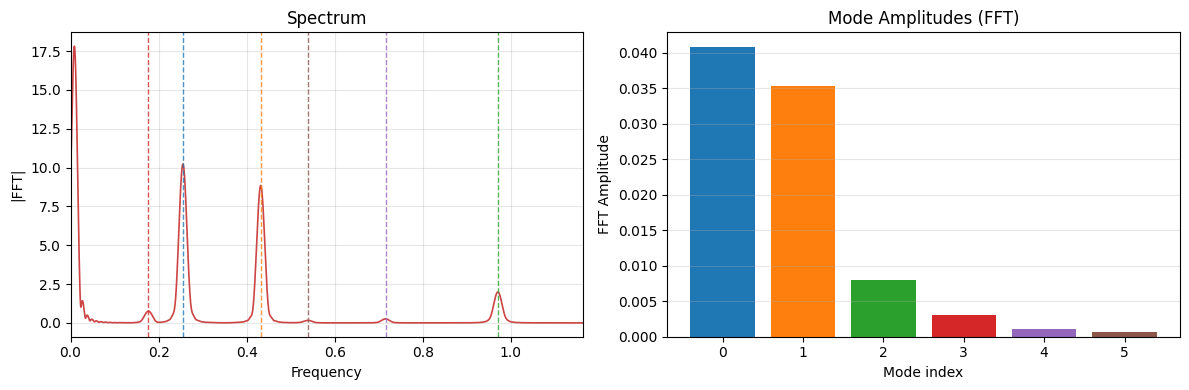


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.255239        5.5647
  2        0.431911        5.2316
  3        0.970500        2.0927
  4        0.176876        5.6728
  5        0.715259        2.8250
  6        0.538976        3.0462


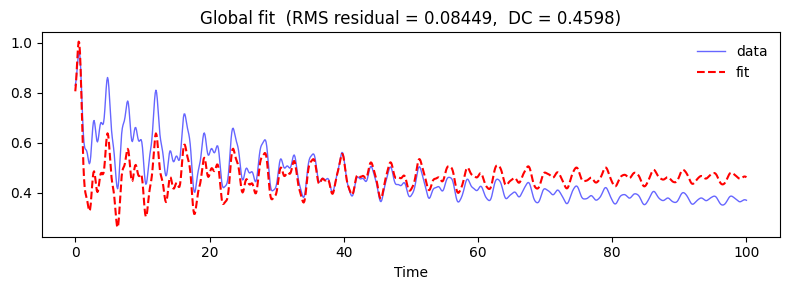

Amplitudes: [5.50682917e-02 4.34677018e-02 2.06328909e-02 3.65803735e-01
 2.96616721e-04 1.80393897e-01]
Decay rates: [2.12741778e-02 1.92131427e-02 3.64322541e-02 1.57562853e+00
 3.49040955e-05 1.85664847e+00]
DC (fitted): 0.45983103599697206   DC (mean): 0.46399931645916703

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.603716        1.603875       -0.000159          -0.010%
   2        2.713776        2.713792       -0.000016          -0.001%
   3        6.097833        6.097835       -0.000002          -0.000%
   4        1.111348        1.109916       +0.001431          +0.129%
   5        4.494108        4.493959       +0.000149          +0.003%
   6        3.386486        3.384043       +0.002443          +0.072%
--------------------------

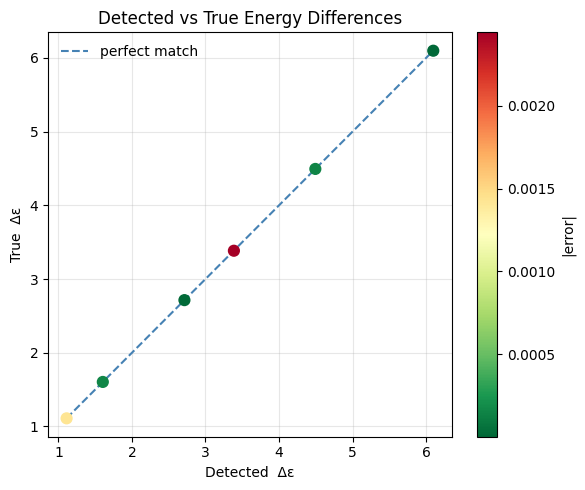

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... found solution explaining 4/6 (67%) of observations.
  Trying match threshold = 20% ... found solution explaining 4/6 (67%) of observations.

  Running greedy solver for comparison...
  Greedy explains 4/6 (67%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.6037), np.float64(2.7113), np.float64(6.0978)]
    Explains 4/6 observed differences (67%)

                  E0      E1      E2      E3
True:         0.0000  1.6039  2.7138  6.0978
Forward:      0.0000  1.6037  2.7113  6.0978  <-- best
Reversed:     0.0000  3.3865  4.4941  6.0978


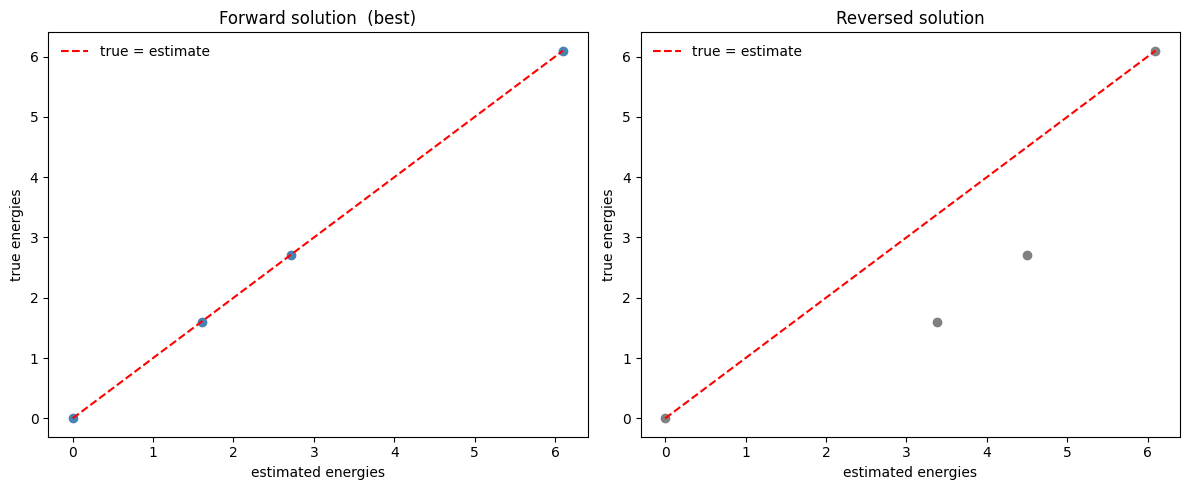

e_m:   [0.     1.6037 2.7138 6.0978]
phi_m: [0.     0.3592 0.5258 2.0952]
u_m:   [0.2844 0.1677 0.7852 0.11  ]
Exact |u_m|: [0.90919677 0.29164099 0.24651995 0.1659358 ]
Exact phases (mod pi, rel to u_0): [0.         0.34583917 0.54067758 2.08449851]


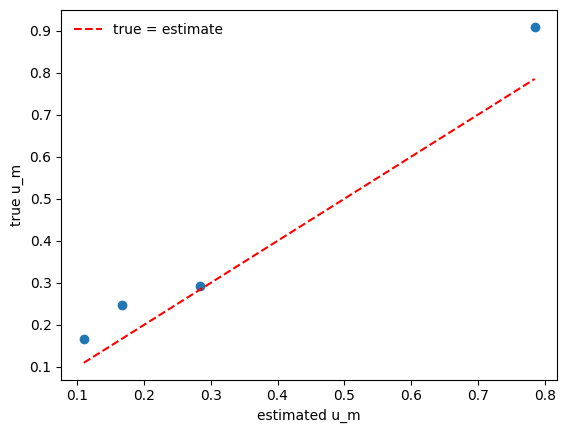

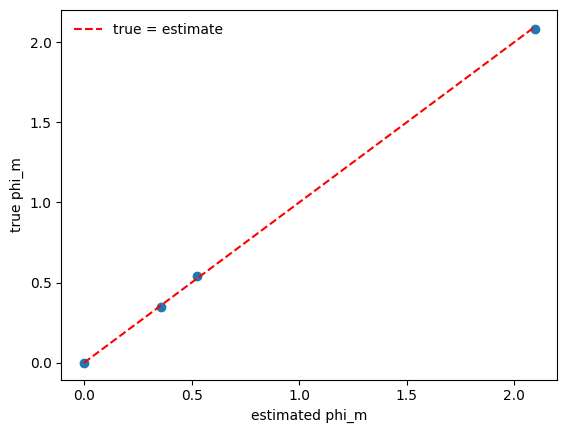

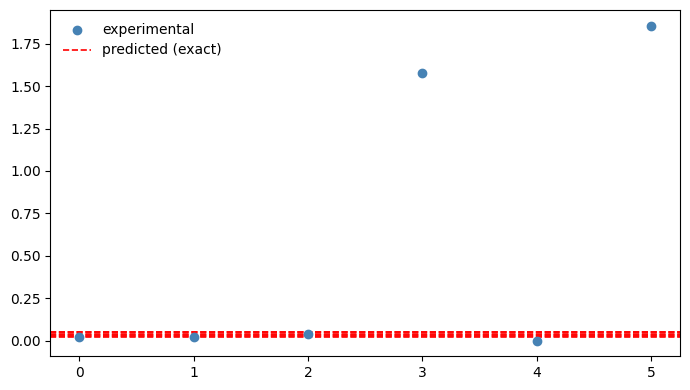

Exact lambdas (predicted): [0.0265 0.0215 0.048  0.048  0.0305 0.0375]
Experimental lambdas: [2.12741778e-02 1.92131427e-02 3.64322541e-02 1.57562853e+00
 3.49040955e-05 1.85664847e+00]

CASE: Ramp+Wait   (r_noise=True, w_noise=True)
  [##############################] 100.00%  iter 1000/1000  elapsed  126.8s  ETA   -0.0s


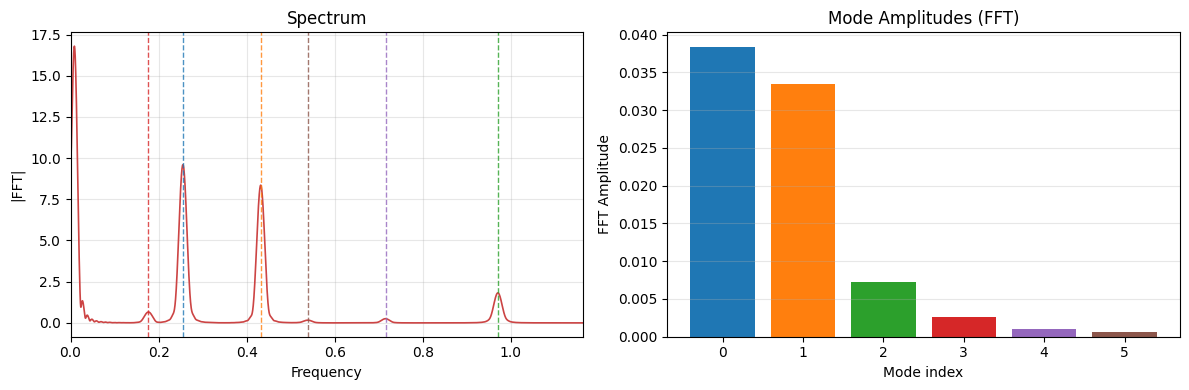


  #       Frequency   Phase (rad)
-----------------------------------
  1        0.255240        5.5741
  2        0.431911        5.2611
  3        0.970496        2.0900
  4        0.176887        5.7044
  5        0.715258        2.7556
  6        0.538926        3.1430


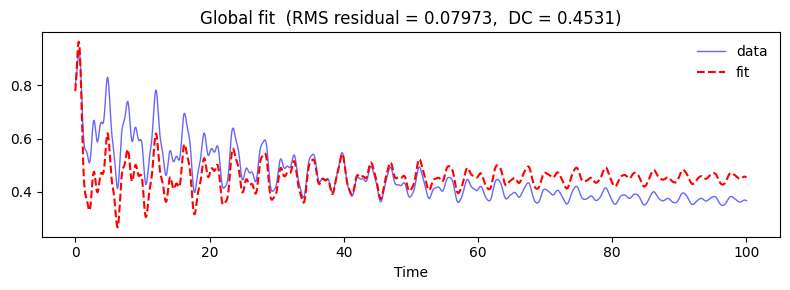

Amplitudes: [0.05185811 0.04096065 0.01894095 0.3285745  0.00038265 0.16355024]
Decay rates: [2.13317534e-02 1.91736262e-02 3.65696598e-02 1.57031319e+00
 1.39780803e-03 1.85982186e+00]
DC (fitted): 0.4531105302202812   DC (mean): 0.45695597684816797

                     Matched energy differences                     
--------------------------------------------------------------------
   #     Detected Δε         True Δε           Error       Error (%)
--------------------------------------------------------------------
   1        1.603717        1.603875       -0.000158          -0.010%
   2        2.713776        2.713792       -0.000016          -0.001%
   3        6.097808        6.097835       -0.000026          -0.000%
   4        1.111414        1.109916       +0.001498          +0.135%
   5        4.494101        4.493959       +0.000142          +0.003%
   6        3.386175        3.384043       +0.002132          +0.063%
----------------------------------------------------

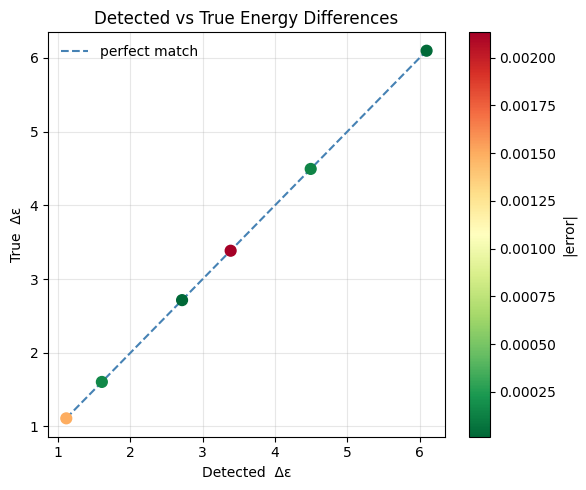

Incomplete Turnpike Solver
  Target levels:        4
  Expected differences: 6
  Observed differences: 6 (100%)

  Trying match threshold = 100% ... no solution at this threshold.
  Trying match threshold = 80% ... no solution at this threshold.
  Trying match threshold = 60% ... no solution at this threshold.
  Trying match threshold = 40% ... found solution explaining 4/6 (67%) of observations.
  Trying match threshold = 20% ... found solution explaining 4/6 (67%) of observations.

  Running greedy solver for comparison...
  Greedy explains 4/6 (67%)

  Final solution (backtracking):
    [np.float64(0.0), np.float64(1.6037), np.float64(2.7116), np.float64(6.0978)]
    Explains 4/6 observed differences (67%)

                  E0      E1      E2      E3
True:         0.0000  1.6039  2.7138  6.0978
Forward:      0.0000  1.6037  2.7116  6.0978  <-- best
Reversed:     0.0000  3.3862  4.4941  6.0978


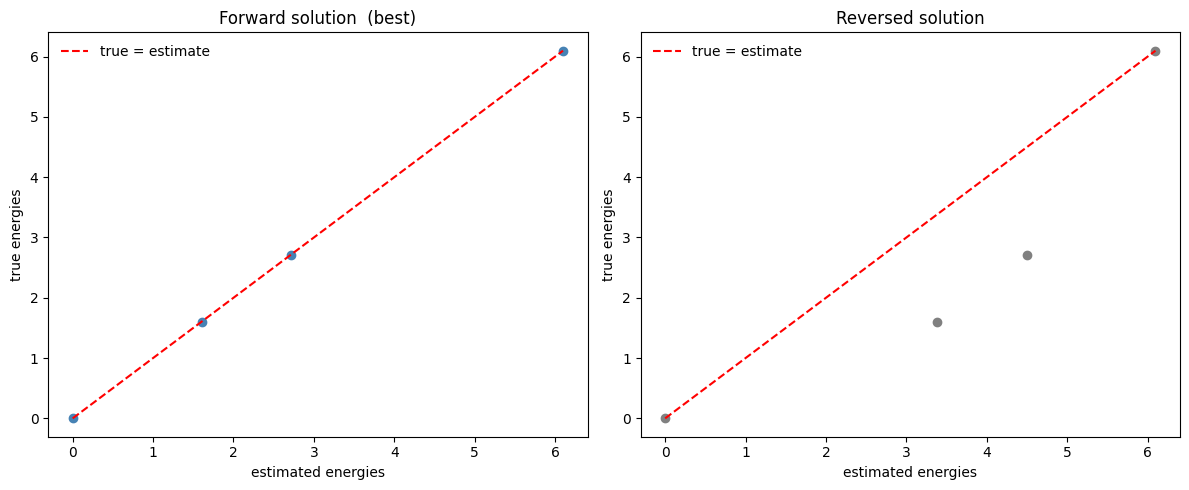

e_m:   [0.     1.6037 2.7138 6.0978]
phi_m: [0.     0.3545 0.5111 2.0966]
u_m:   [0.2836 0.1799 0.7712 0.1175]
Exact |u_m|: [0.90919677 0.29164099 0.24651995 0.1659358 ]
Exact phases (mod pi, rel to u_0): [0.         0.34583917 0.54067758 2.08449851]


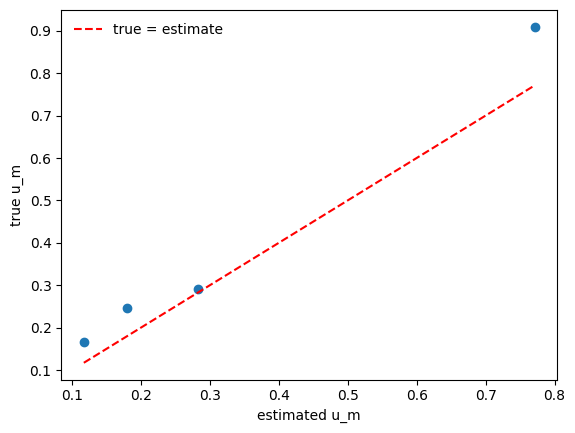

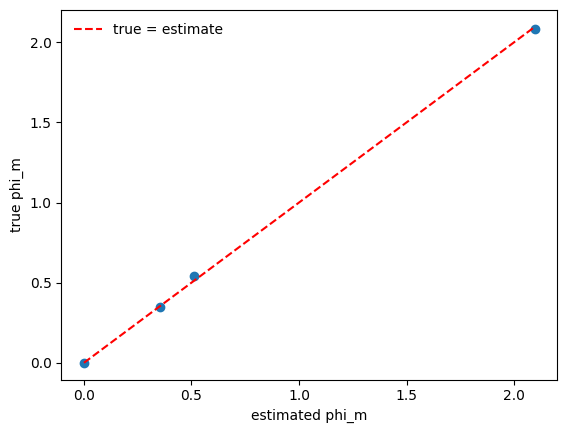

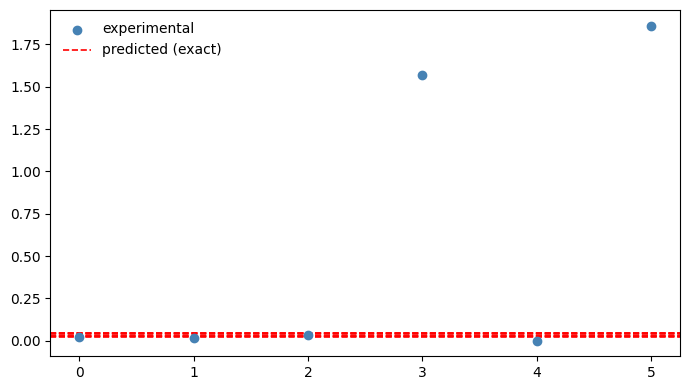

Exact lambdas (predicted): [0.0265 0.0215 0.048  0.048  0.0305 0.0375]
Experimental lambdas: [2.13317534e-02 1.91736262e-02 3.65696598e-02 1.57031319e+00
 1.39780803e-03 1.85982186e+00]


In [5]:
CASES = [
    # label,        r_noise, w_noise
    ('Noiseless',   False,   False),
    ('Ramp only',   True,    False),
    ('Wait only',   False,   True),
    ('Ramp+Wait',   True,    True),
]

run_results = {}
for label, r_noise, w_noise in CASES:
    print('\n' + '=' * 70)
    print(f'CASE: {label}   (r_noise={r_noise}, w_noise={w_noise})')
    print('=' * 70)

    set_global_seed(noise_seed)
    pc_list = run_experiment_sweep(
        n_qubits, epsilon, H_target_dict, ramp_time, tw_l, dt,
        up_assym_list=up_assymetry_coefficients,
        down_assym_list=down_assymetry_coefficients,
        r_noise=r_noise, w_noise=w_noise,
        gamma_dec_list=t1_rates, gamma_dep_list=t2_rates,
        initial_state=psi0,
        ramp_error=average_ramp_error, wait_error=average_wait_error,
    )

    noisy = r_noise or w_noise
    results = run_full_diagnostics(
        pc_list, tw_l, n_qubits, epsilon, H_target_dict,
        ramp_time, dt, egvals_midpoint,
        w_noise=noisy,                       # fit decay rates whenever any noise is on
        t1_rates=t1_rates if noisy else None,
        t2_rates=t2_rates if noisy else None,
        initial_state=psi0,
        up_assym_list=up_assymetry_coefficients,
        down_assym_list=down_assymetry_coefficients,
    )
    run_results[label] = results

## Align detected modes across runs

Every run's detected energy differences are matched to the true transitions (Hungarian
matching on `|detected − true|`), so column *k* refers to the same physical transition in
all four runs. Missing modes become `NaN` for that run.

In [6]:
aligned_by_case = {
    label: aligned_from_results(run_results[label], true_differences)
    for label, _, _ in CASES
}

# Quick look at how many transitions each run actually resolved.
for label in aligned_by_case:
    n_found = np.isfinite(aligned_by_case[label]['energy']).sum()
    print(f'{label:>10}: {n_found}/{len(true_differences)} transitions matched')

 Noiseless: 6/6 transitions matched
 Ramp only: 6/6 transitions matched
 Wait only: 6/6 transitions matched
 Ramp+Wait: 6/6 transitions matched


## 1. Noiseless baseline vs theory

Before computing noisy differences we confirm the noiseless run reproduces the theory:
frequencies vs true transition frequencies, energy levels vs the true spectrum, and the
recovered amplitudes/phases vs the exact-state-vector values.

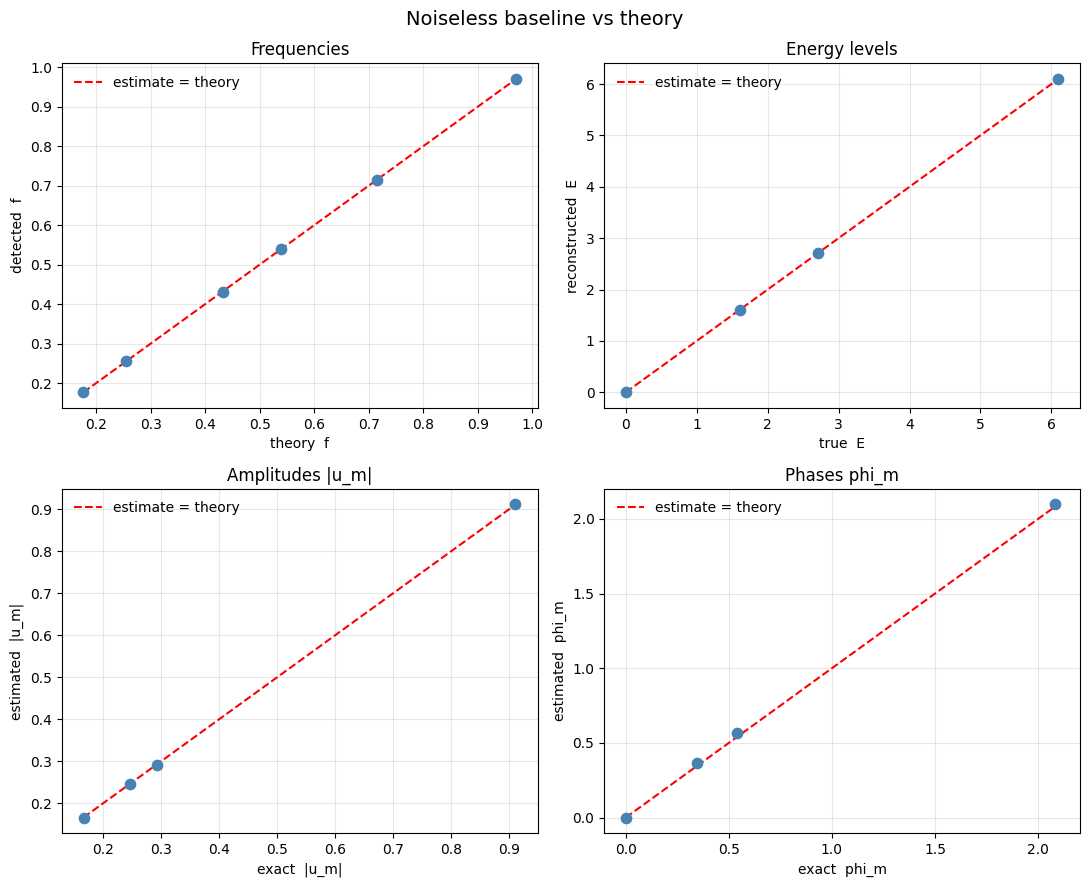

In [7]:
base_res = run_results['Noiseless']
plot_baseline_vs_theory(
    aligned_by_case['Noiseless'], true_differences,
    experimental_energies=base_res['experimental_energies'],
    shifted_true_energies=base_res['shifted_true_energies'],
    u_m=base_res['u_m'],
    u_exact_amplitudes=base_res['u_exact_amplitudes'],
    phi_m=base_res['phi_m'],
    u_exact_phases_rel=base_res['u_exact_phases_rel'],
)

## 1b. Per-run vs theory (all four runs)

For every run, two combined images comparing the recovered spectrum to theory:

- **Scatter** — estimate vs theory with a `y = x` line (the original style, now all four
  quantities in one image).
- **Index** — x-axis is the transition / level / mode index, with theory and experimental
  overlaid as two lines per panel. Deviations read off as the vertical gap, and the slope
  is the same in every panel (unlike the scatter, whose `y = x` slope depends on the
  quantity's range).

Frequencies and energies use the per-transition / per-level true reference; amplitudes and
phases use the sorted exact-state-vector values, consistent with the baseline plot.

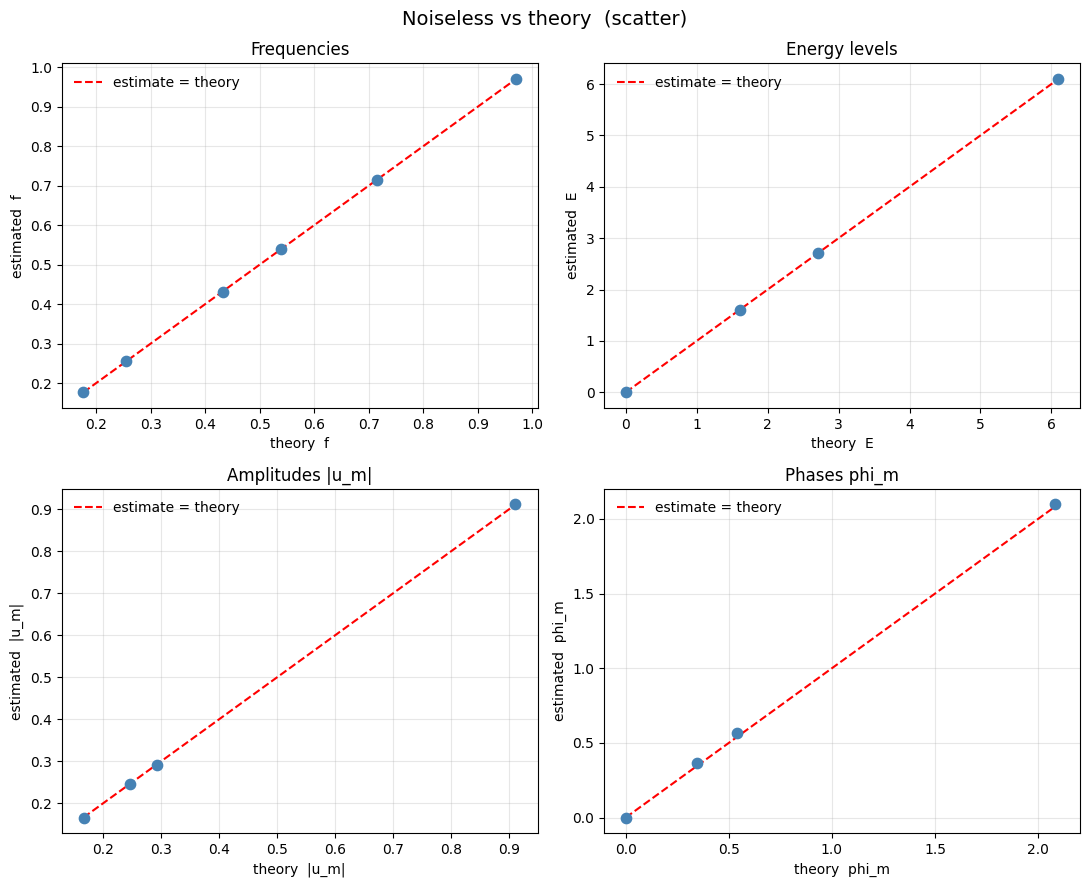

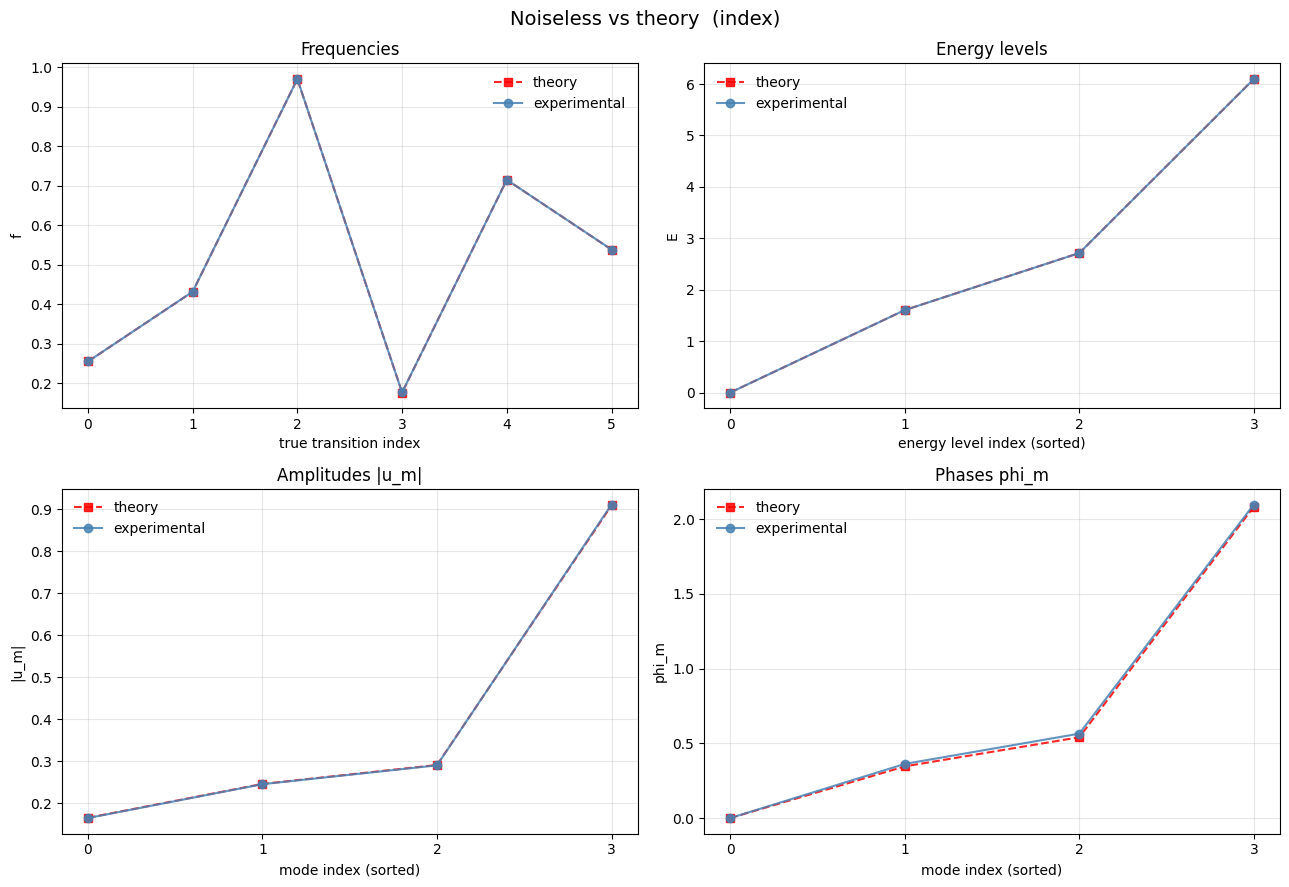

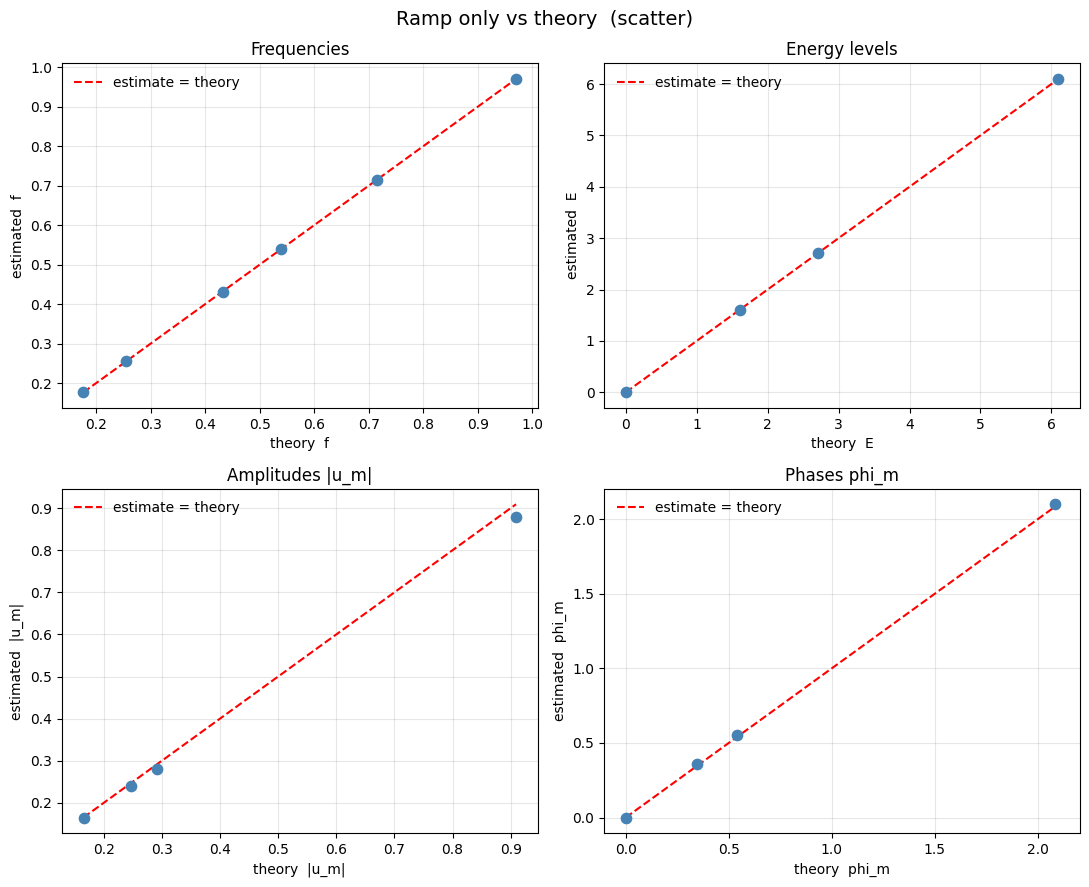

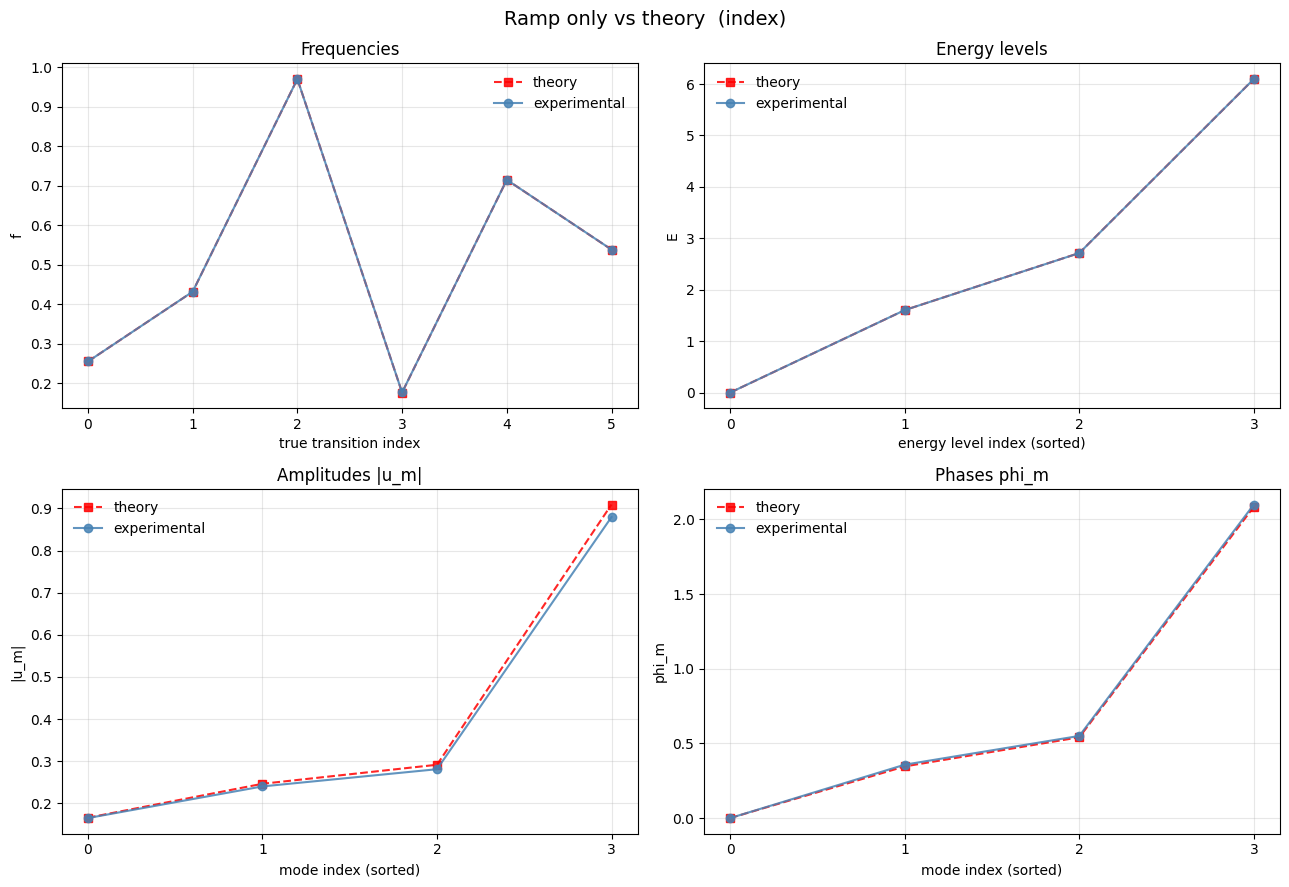

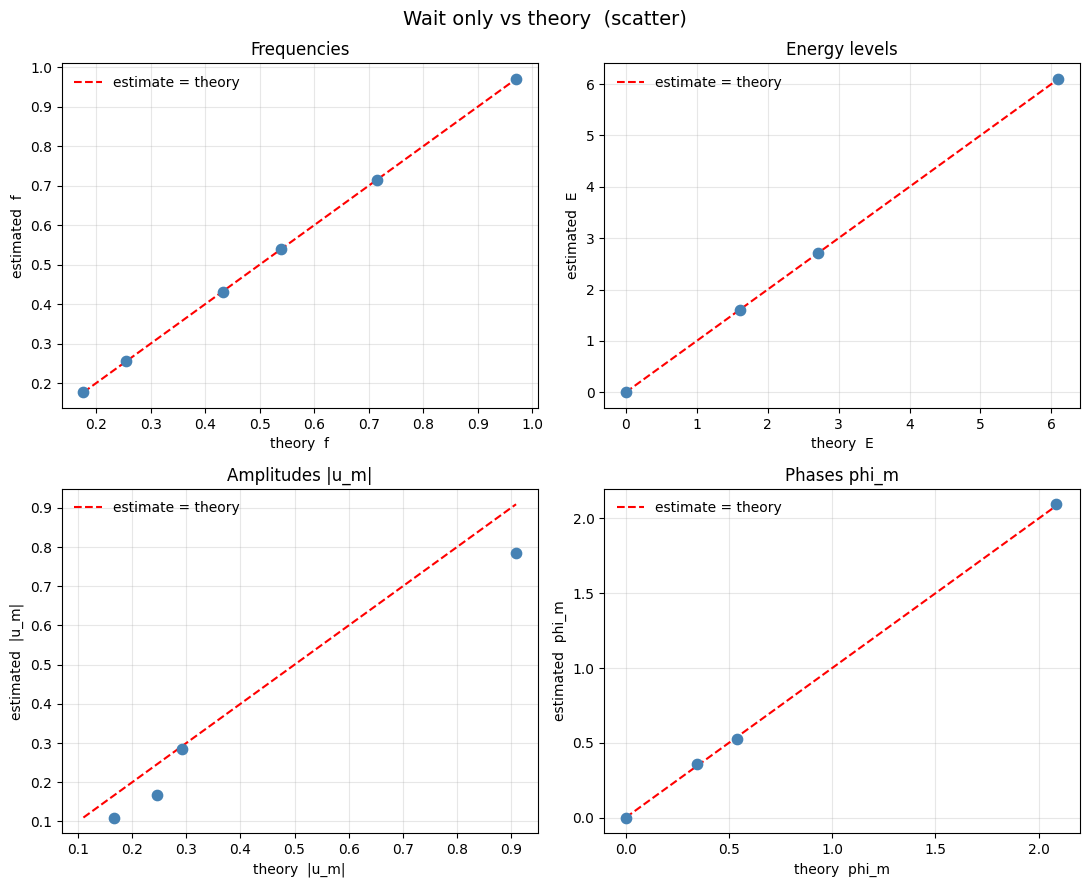

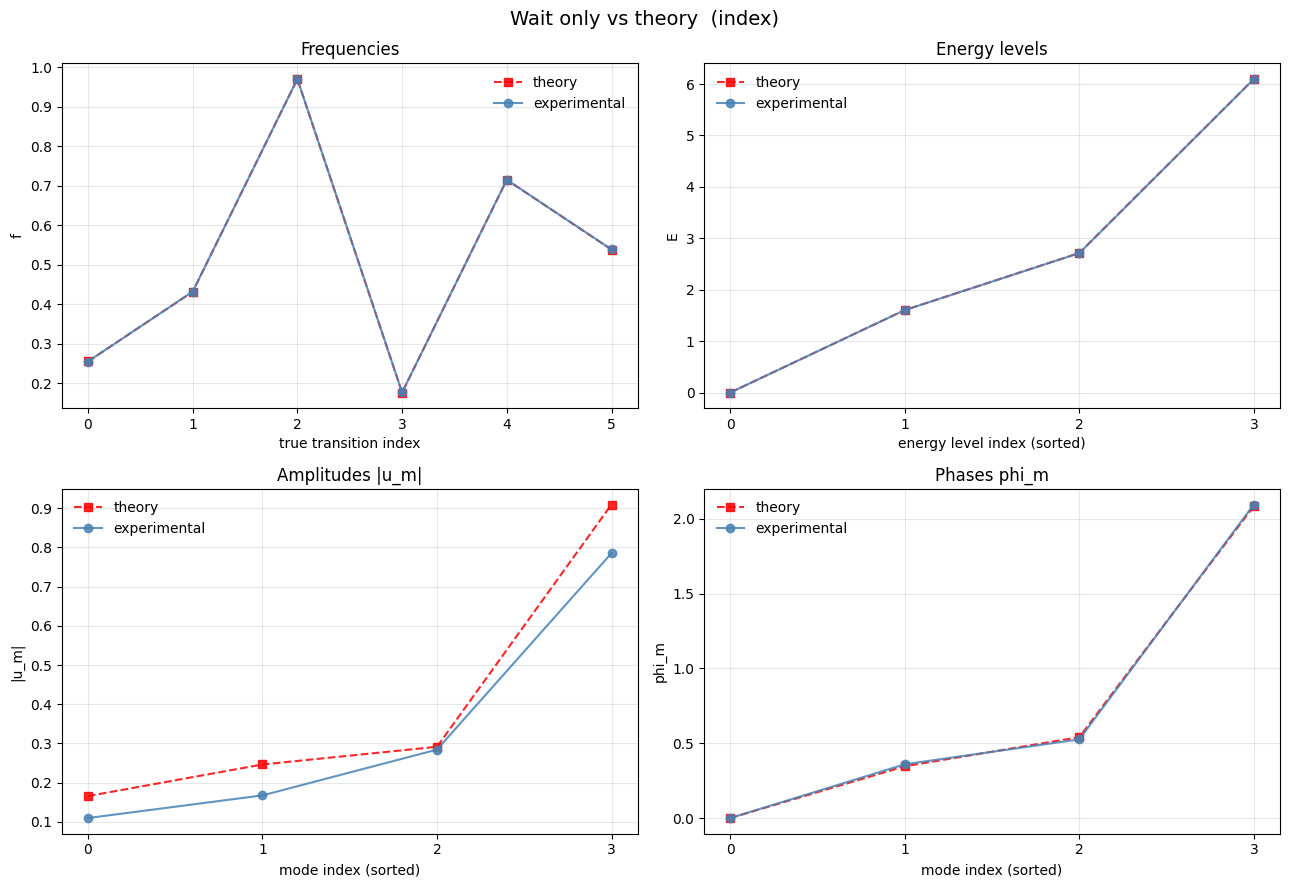

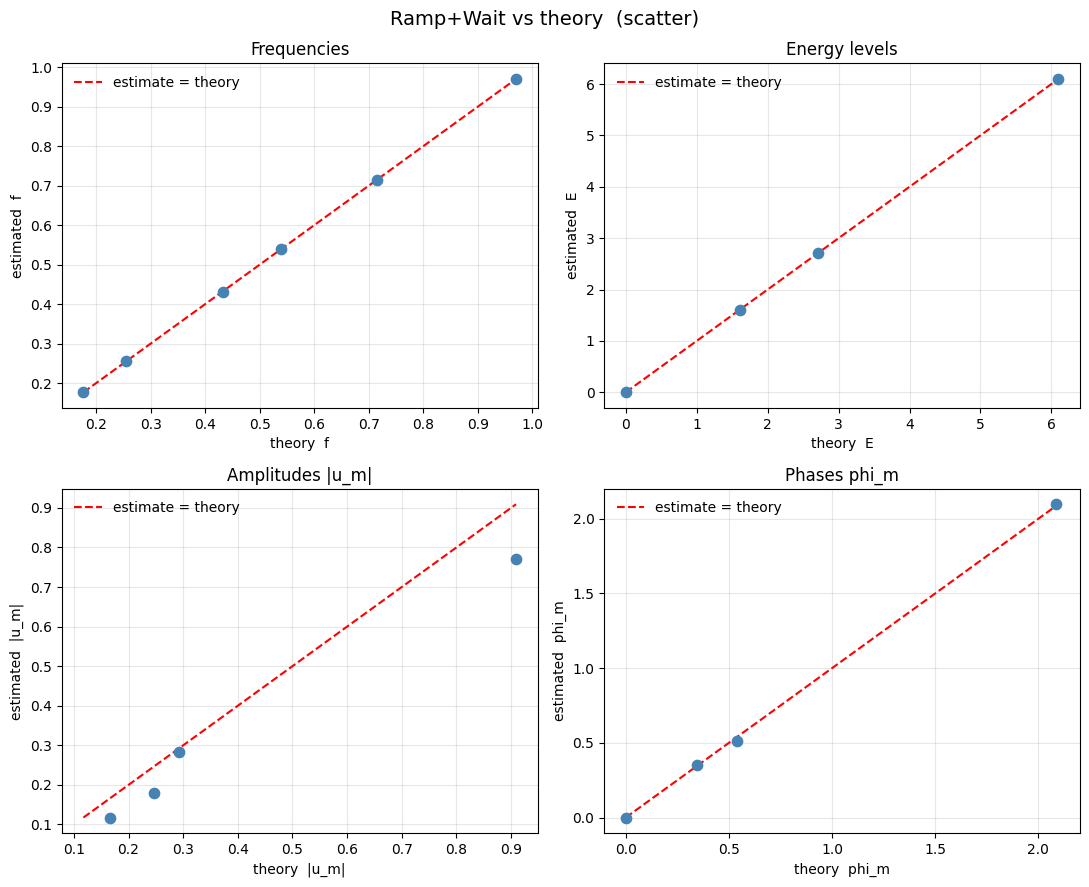

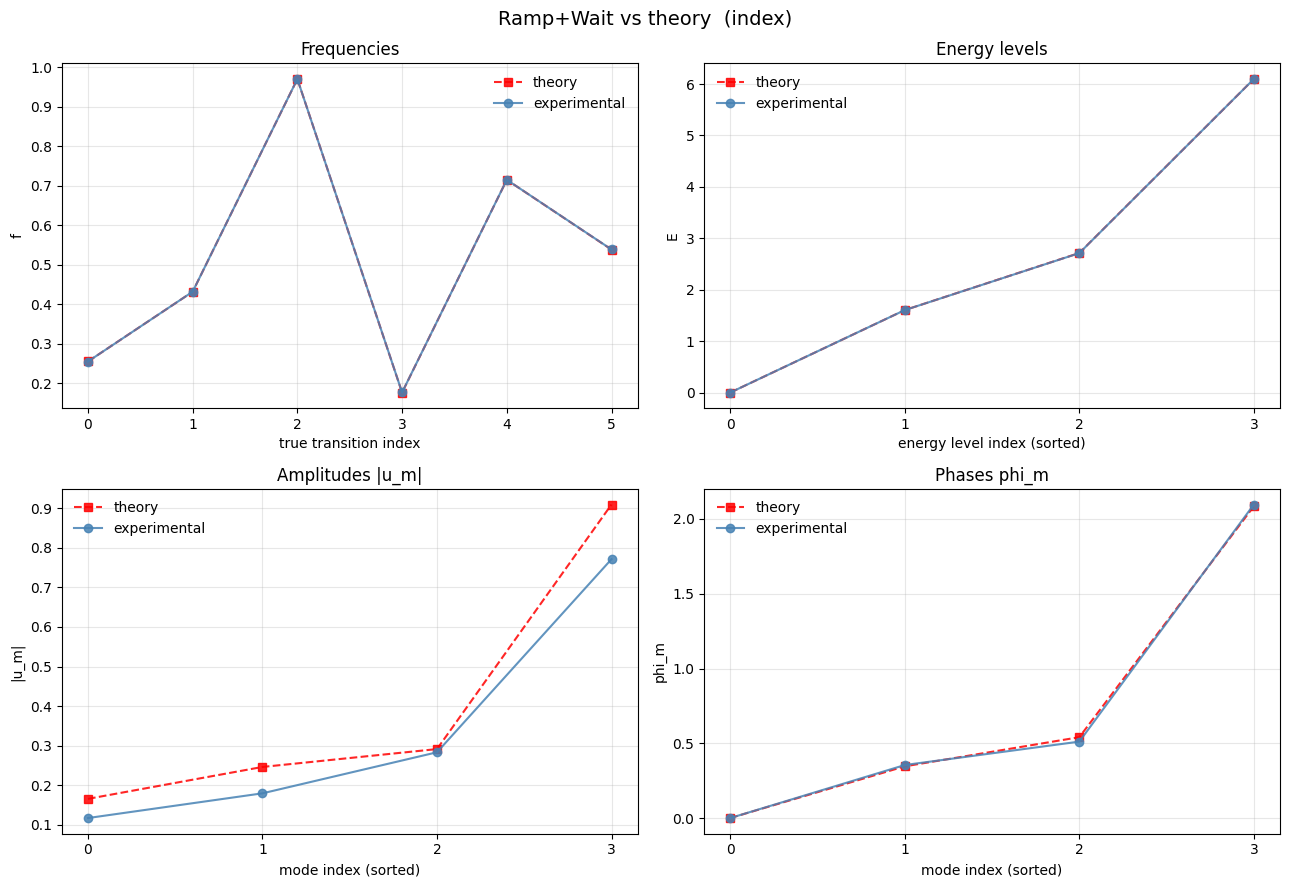

In [8]:
for label, _, _ in CASES:
    plot_run_vs_theory_scatter(
        aligned_by_case[label], run_results[label], true_differences, label)
    plot_run_vs_theory_index(
        aligned_by_case[label], run_results[label], true_differences, label)

## 2. Noisy runs vs noiseless baseline

Per-transition difference (noisy − noiseless) in frequency, energy difference, amplitude
and phase, for each of the three noisy cases. Phase differences are wrapped to (−π, π].

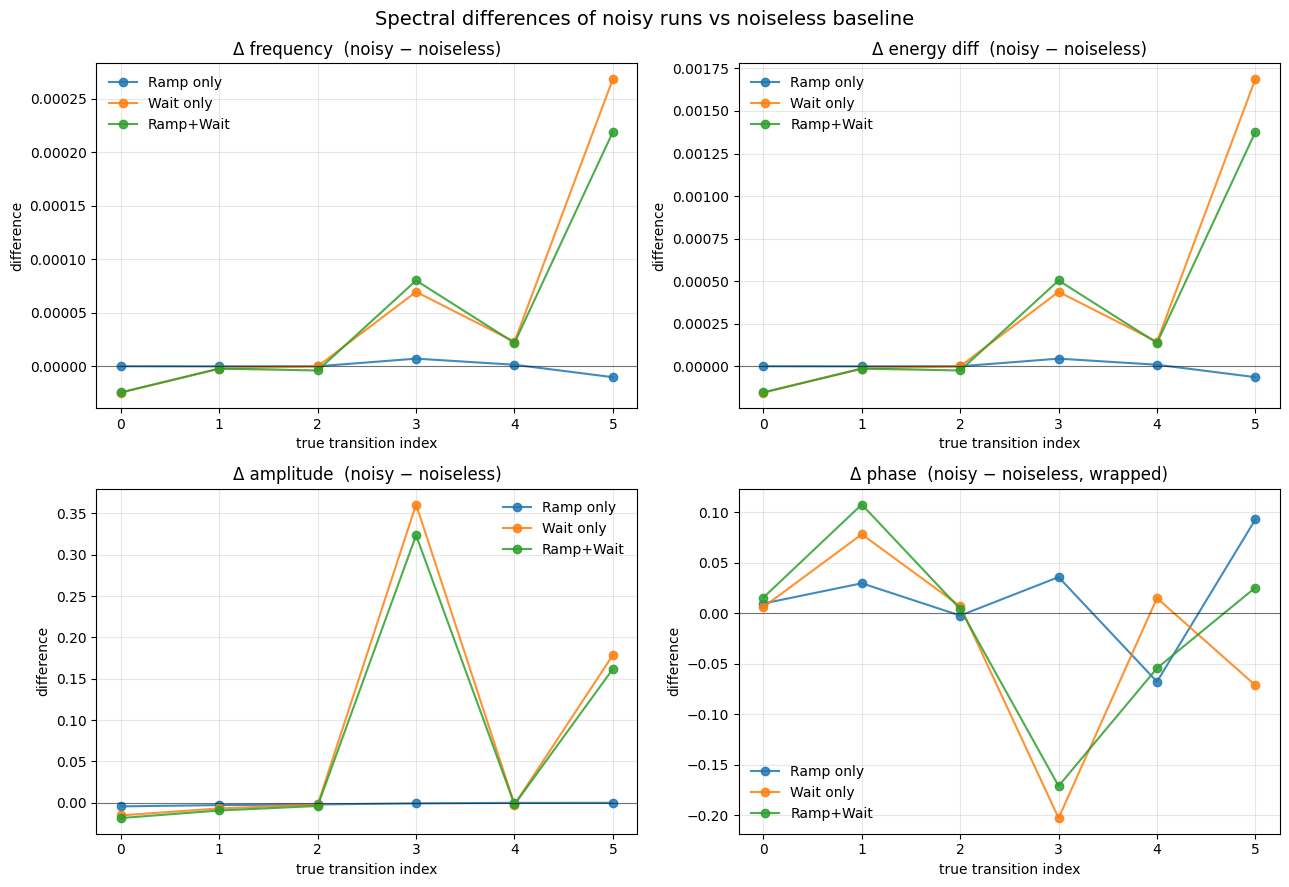

In [11]:
plot_noisy_differences(
    aligned_by_case, true_differences,
    case_labels=['Ramp only', 'Wait only', 'Ramp+Wait'],
)

## 3. Noise estimation vs configured real rates

For the cases that contain wait noise, the global fit estimates per-mode coherence decay
rates (`lambdas`). We compare those against the real configured rates `Γ_mn` predicted
from the per-qubit `t1_rates` / `t2_rates`.

> Ramp-only noise is not included here: its decay does not map onto the wait-time
> `Γ_mn` model, so there is no like-for-like real rate to compare against.

Real Γ_mn (configured): [0.0215 0.0265 0.0305 0.0375 0.048  0.048 ]
 Wait only estimated: [3.00000e-05 1.92100e-02 2.12700e-02 3.64300e-02 1.57563e+00 1.85665e+00]
 Ramp+Wait estimated: [1.40000e-03 1.91700e-02 2.13300e-02 3.65700e-02 1.57031e+00 1.85982e+00]


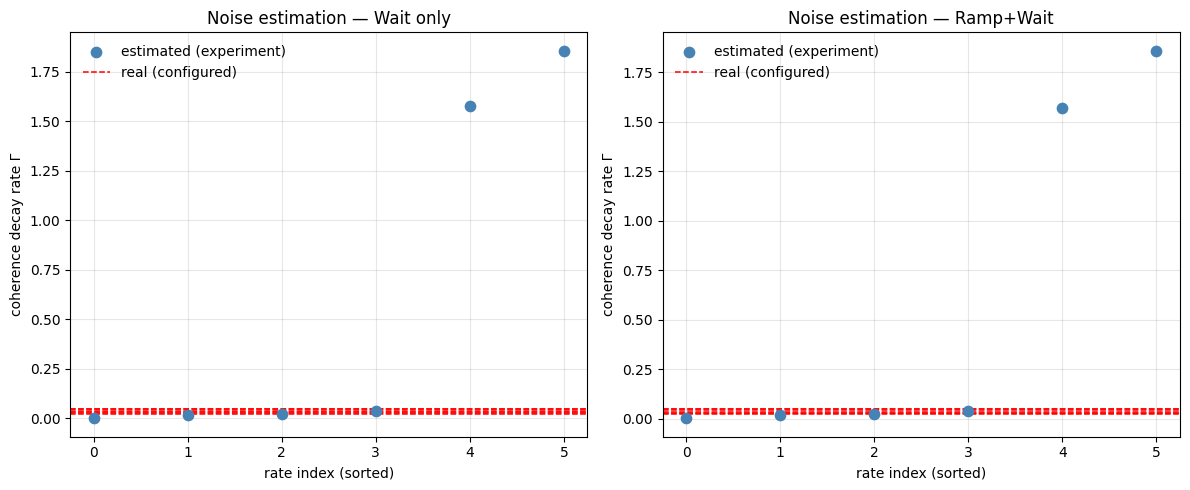

In [10]:
real_rates = predict_gamma_rates(t1_rates, t2_rates)
print('Real Γ_mn (configured):', np.round(np.sort(real_rates), 5))

estimation_by_case = {
    label: {'estimated': run_results[label]['lambdas']}
    for label in ('Wait only', 'Ramp+Wait')
}
for label, d in estimation_by_case.items():
    print(f'{label:>10} estimated:', np.round(np.sort(d['estimated']), 5))

plot_noise_estimation(
    estimation_by_case, real_rates,
    case_labels=['Wait only', 'Ramp+Wait'],
)